In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN

from prophet import Prophet   
from sklearn.cluster import DBSCAN

c:\Users\rakhi\OneDrive\Desktop\infosys-spring board\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
df = pd.read_csv("../outputs/processed_data.csv")

df['timestamp'] = pd.to_datetime(df['timestamp'])
df.sort_values('timestamp', inplace=True)

In [8]:
window = 10

df['hr_mean'] = df['heart_rate_bpm'].rolling(window).mean()
df['hr_std'] = df['heart_rate_bpm'].rolling(window).std()

df['steps_mean'] = df['steps'].rolling(window).mean()
df['steps_std'] = df['steps'].rolling(window).std()

df['spo2_mean'] = df['spo2_pct'].rolling(window).mean()
df['spo2_std'] = df['spo2_pct'].rolling(window).std()

df.fillna(0, inplace=True)

In [9]:
features = df[['heart_rate_bpm','steps','spo2_pct',
               'hr_mean','hr_std',
               'steps_mean','steps_std',
               'spo2_mean','spo2_std']]

In [10]:
scaler = StandardScaler()
X = scaler.fit_transform(features)

In [11]:
dbscan = DBSCAN(eps=0.5, min_samples=5)

df['dbscan'] = dbscan.fit_predict(X)

print("DBSCAN outliers:", (df['dbscan'] == -1).sum())

DBSCAN outliers: 373


In [12]:
features.to_csv("../outputs/feature_matrix.csv", index=False)

16:28:09 - cmdstanpy - INFO - Chain [1] start processing
16:28:35 - cmdstanpy - INFO - Chain [1] done processing


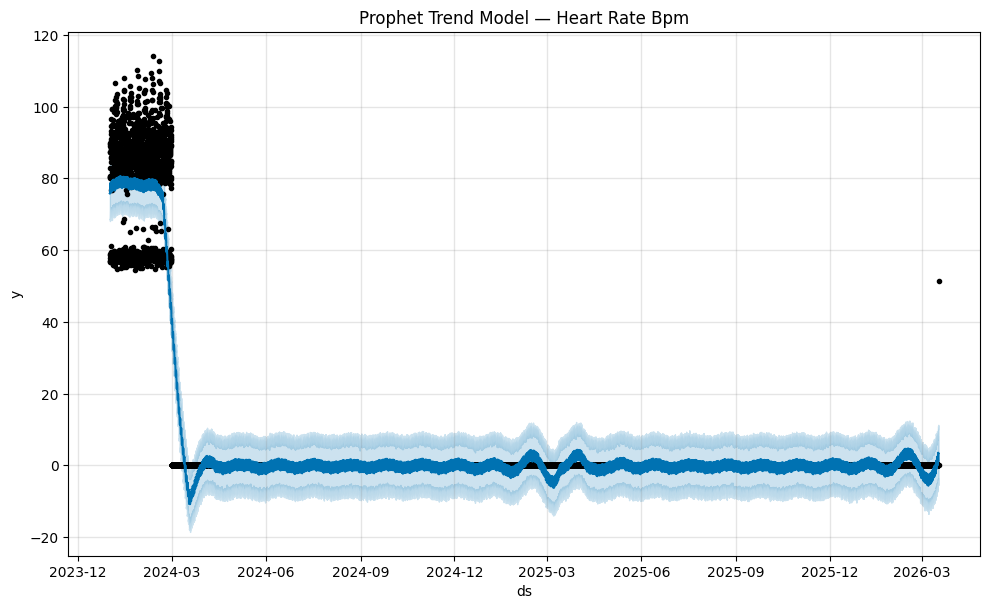

In [13]:
prophet_df = df[['timestamp','heart_rate_bpm']].rename(
    columns={'timestamp':'ds','heart_rate_bpm':'y'}
)

model = Prophet()
model.fit(prophet_df)

future = model.make_future_dataframe(periods=0)
forecast = model.predict(future)

fig = model.plot(forecast)
plt.title("Prophet Trend Model — Heart Rate Bpm")

plt.savefig("../outputs/prophet_heart_rate_bpm.png")
plt.show()

16:28:43 - cmdstanpy - INFO - Chain [1] start processing
16:28:56 - cmdstanpy - INFO - Chain [1] done processing


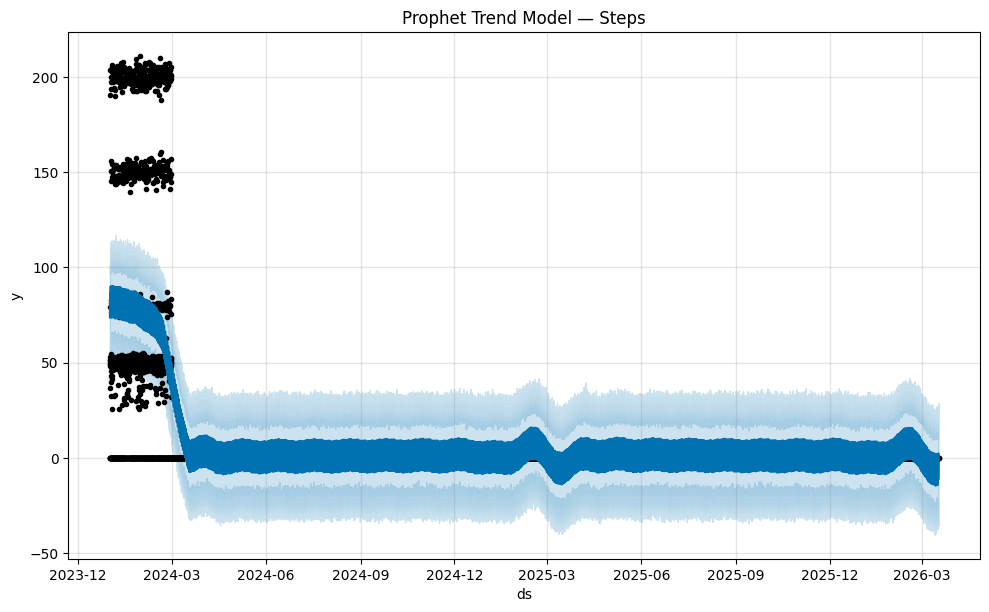

In [14]:
prophet_df = df[['timestamp','steps']].rename(
    columns={'timestamp':'ds','steps':'y'}
)

model = Prophet()
model.fit(prophet_df)

future = model.make_future_dataframe(periods=0)
forecast = model.predict(future)

fig = model.plot(forecast)
plt.title("Prophet Trend Model — Steps")

plt.savefig("../outputs/prophet_steps.png")
plt.show()

16:29:04 - cmdstanpy - INFO - Chain [1] start processing
16:29:23 - cmdstanpy - INFO - Chain [1] done processing


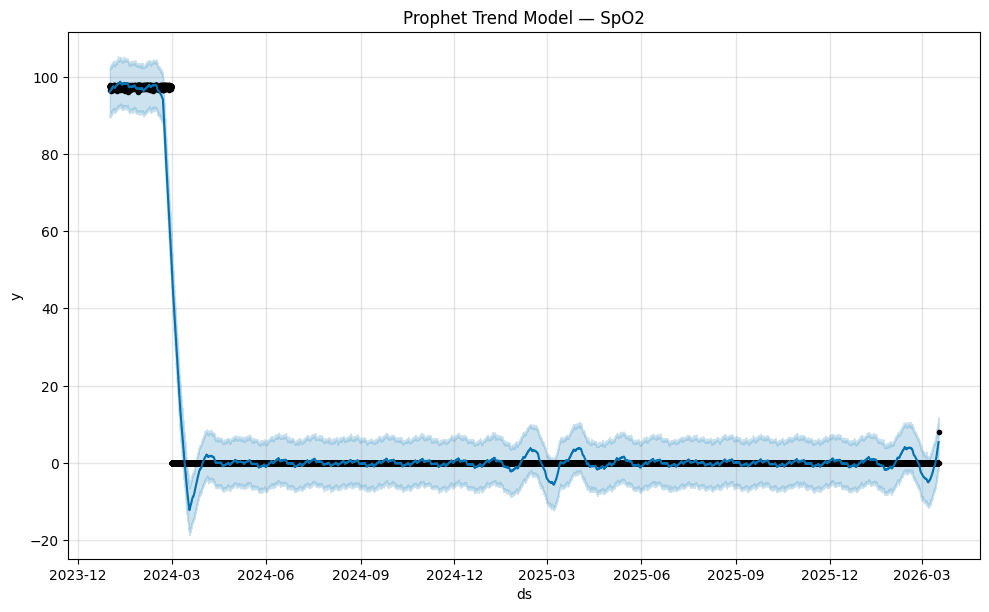

In [15]:
prophet_df = df[['timestamp','spo2_pct']].rename(
    columns={'timestamp':'ds','spo2_pct':'y'}
)

model = Prophet()
model.fit(prophet_df)

future = model.make_future_dataframe(periods=0)
forecast = model.predict(future)

fig = model.plot(forecast)
plt.title("Prophet Trend Model — SpO2")

plt.savefig("../outputs/prophet_spo2_pct.png")
plt.show()

In [16]:
scaler = StandardScaler()
X = scaler.fit_transform(features)

In [17]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

print("KMeans clusters:", np.unique(df['cluster']))

KMeans clusters: [0 1 2 3]


In [18]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['dbscan'] = dbscan.fit_predict(X)

print("DBSCAN outliers:", (df['dbscan'] == -1).sum())

DBSCAN outliers: 373


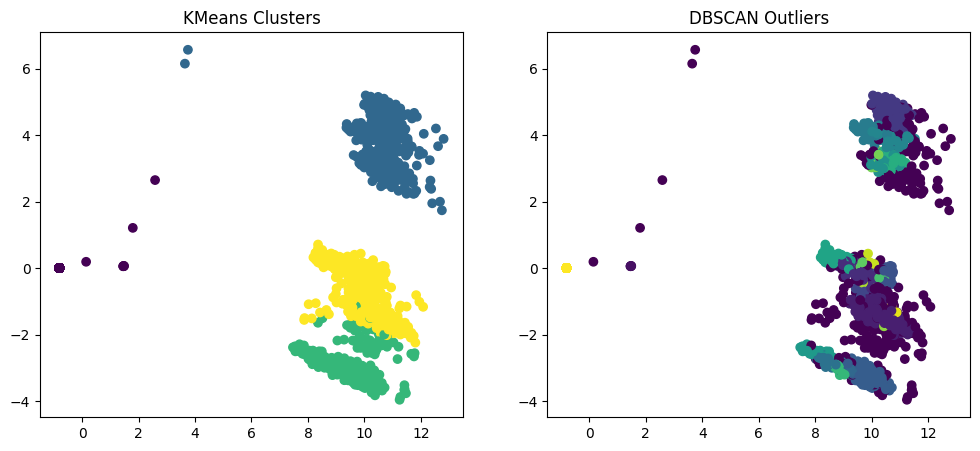

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(12,5))

# KMeans plot
plt.subplot(1,2,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'])
plt.title("KMeans Clusters")

# DBSCAN plot
plt.subplot(1,2,2)
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['dbscan'])
plt.title("DBSCAN Outliers")

plt.savefig("../outputs/milestone2_clusters.png")
plt.show()

In [21]:
df.head()

,timestamp,heart_rate_bpm,steps,sleeping,spo2_pct,calories_burned,hour,day_of_week,is_weekend,is_anomaly,...,z_score,anomaly,hr_mean,hr_std,steps_mean,steps_std,spo2_mean,spo2_std,dbscan,cluster
0,2024-01-01 00:00:00,57.925000,0.0,1.0,97.341667,2.911667,0.0,0.0,0.0,0.0,...,0.0,False,0.0,0.0,0.0,0.0,0.0,0.0,0,0
1,2024-01-01 01:00:00,57.108333,0.0,1.0,97.741667,2.796667,1.0,0.0,0.0,0.0,...,0.0,False,0.0,0.0,0.0,0.0,0.0,0.0,0,0
2,2024-01-01 02:00:00,57.066667,0.0,1.0,97.625000,3.045000,2.0,0.0,0.0,0.0,...,0.0,False,0.0,0.0,0.0,0.0,0.0,0.0,0,0
3,2024-01-01 03:00:00,58.525000,0.0,1.0,97.708333,2.824167,3.0,0.0,0.0,0.0,...,0.0,False,0.0,0.0,0.0,0.0,0.0,0.0,0,0
4,2024-01-01 04:00:00,58.933333,0.0,1.0,97.358333,3.250833,4.0,0.0,0.0,0.0,...,0.0,False,0.0,0.0,0.0,0.0,0.0,0.0,0,0


In [22]:
df.head()

,timestamp,heart_rate_bpm,steps,sleeping,spo2_pct,calories_burned,hour,day_of_week,is_weekend,is_anomaly,...,z_score,anomaly,hr_mean,hr_std,steps_mean,steps_std,spo2_mean,spo2_std,dbscan,cluster
0,2024-01-01 00:00:00,57.925000,0.0,1.0,97.341667,2.911667,0.0,0.0,0.0,0.0,...,0.0,False,0.0,0.0,0.0,0.0,0.0,0.0,0,0
1,2024-01-01 01:00:00,57.108333,0.0,1.0,97.741667,2.796667,1.0,0.0,0.0,0.0,...,0.0,False,0.0,0.0,0.0,0.0,0.0,0.0,0,0
2,2024-01-01 02:00:00,57.066667,0.0,1.0,97.625000,3.045000,2.0,0.0,0.0,0.0,...,0.0,False,0.0,0.0,0.0,0.0,0.0,0.0,0,0
3,2024-01-01 03:00:00,58.525000,0.0,1.0,97.708333,2.824167,3.0,0.0,0.0,0.0,...,0.0,False,0.0,0.0,0.0,0.0,0.0,0.0,0,0
4,2024-01-01 04:00:00,58.933333,0.0,1.0,97.358333,3.250833,4.0,0.0,0.0,0.0,...,0.0,False,0.0,0.0,0.0,0.0,0.0,0.0,0,0


In [23]:
df.to_csv("../outputs/features.csv", index=False)

In [24]:
df_check = pd.read_csv("../outputs/features.csv")

df_check.head()

,timestamp,heart_rate_bpm,steps,sleeping,spo2_pct,calories_burned,hour,day_of_week,is_weekend,is_anomaly,...,z_score,anomaly,hr_mean,hr_std,steps_mean,steps_std,spo2_mean,spo2_std,dbscan,cluster
0,2024-01-01 00:00:00,57.925000,0.0,1.0,97.341667,2.911667,0.0,0.0,0.0,0.0,...,0.0,False,0.0,0.0,0.0,0.0,0.0,0.0,0,0
1,2024-01-01 01:00:00,57.108333,0.0,1.0,97.741667,2.796667,1.0,0.0,0.0,0.0,...,0.0,False,0.0,0.0,0.0,0.0,0.0,0.0,0,0
2,2024-01-01 02:00:00,57.066667,0.0,1.0,97.625000,3.045000,2.0,0.0,0.0,0.0,...,0.0,False,0.0,0.0,0.0,0.0,0.0,0.0,0,0
3,2024-01-01 03:00:00,58.525000,0.0,1.0,97.708333,2.824167,3.0,0.0,0.0,0.0,...,0.0,False,0.0,0.0,0.0,0.0,0.0,0.0,0,0
4,2024-01-01 04:00:00,58.933333,0.0,1.0,97.358333,3.250833,4.0,0.0,0.0,0.0,...,0.0,False,0.0,0.0,0.0,0.0,0.0,0.0,0,0
